In [8]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt

# 1. Configuracion de rutas
BASE_DIR = os.path.abspath(os.getcwd())
PROCESSED_DIR = os.path.join(BASE_DIR, "..", "data", "processed")

# 2. Carga del GeoJSON analizado en el Notebook 02
ruta_final = os.path.join(PROCESSED_DIR, "vulnerabilidad_final_analizada.geojson")
gdf_analisis = gpd.read_file(ruta_final)

print(f"Base de datos cargada: {len(gdf_analisis)} municipios listos para analisis focalizado.")

Base de datos cargada: 2456 municipios listos para analisis focalizado.


C:\Users\Jafet\AppData\Local\Temp\ipykernel_6212\1286553748.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper right')
C:\Users\Jafet\AppData\Local\Temp\ipykernel_6212\1286553748.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


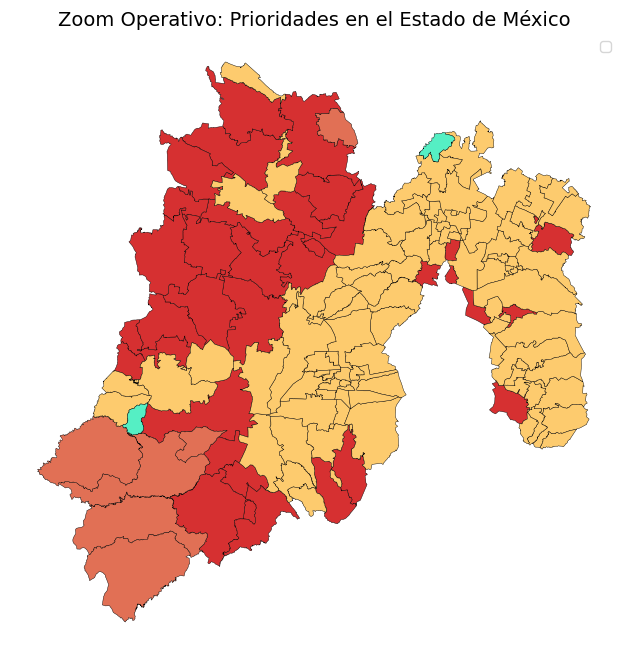

Poblacion en estado CRITICO en México: 3,816,298 habitantes.


In [9]:
# 1. Filtrar por Estado (Estado de México en este ejemplo)
# Puedes cambiar 'México' por 'Puebla' o cualquier otro NOM_EDO de tu Top 15
estado_objetivo = 'México'
gdf_focalizado = gdf_analisis[gdf_analisis['NOM_EDO'] == estado_objetivo].copy()

# 2. Visualizacion del area de intervencion
fig, ax = plt.subplots(figsize=(10, 8))

# Dibujar municipios del estado segun su categoria de prioridad
colores = {'1. CRITICO': '#d63031', '2. SOCIAL': '#e17055', '3. HIDRICO': '#fdcb6e', '4. ESTABLE': '#55efc4'}

for cat, color in colores.items():
    subset = gdf_focalizado[gdf_focalizado['categoria_prioridad'].str.contains(cat)]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.3, label=cat)

plt.title(f"Zoom Operativo: Prioridades en el Estado de {estado_objetivo}", fontsize=14)
plt.legend(loc='upper right')
plt.axis('off')
plt.show()

# 3. Cuantificacion local
pob_critica_local = gdf_focalizado[gdf_focalizado['categoria_prioridad'].str.contains('1. CRITICO')]['Poblacion total'].sum()
print(f"Poblacion en estado CRITICO en {estado_objetivo}: {pob_critica_local:,.0f} habitantes.")

In [10]:
# 1. Analisis de indicadores clave para los municipios criticos del estado
df_resumen_local = gdf_focalizado[gdf_focalizado['categoria_prioridad'].str.contains('1. CRITICO')].copy()

# 2. Calculo de deficit per capita promedio en la zona critica
# El deficit esta en m3/año, lo pasamos a litros/persona/dia (lpd)
df_resumen_local['lpd_deficit'] = (abs(df_resumen_local['DMA_NEGATI']) * 1000) / (df_resumen_local['Poblacion total'] * 365)

print(f"--- DIAGNOSTICO TECNICO: {estado_objetivo} (ZONAS CRITICAS) ---")
display(df_resumen_local[['NOM_MUN', 'Poblacion total', 'DMA_NEGATI', 'lpd_deficit']].sort_values(by='Poblacion total', ascending=False).head(10))

--- DIAGNOSTICO TECNICO: México (ZONAS CRITICAS) ---


,NOM_MUN,Poblacion total,DMA_NEGATI,lpd_deficit
713,Nezahualcóyotl,1077208,-480.429914,0.001222
759,Tlalnepantla de Baz,672202,-480.429914,0.001958
675,Coacalco de Berriozábal,293444,-480.429914,0.004486
684,Chicoloapan,200750,-149.805124,0.002044
660,Almoloya de Juárez,174587,-128.715560,0.002020
697,Ixtlahuaca,160139,-128.715560,0.002202
729,San Felipe del Progreso,144924,-6.760647,0.000128
769,Villa Victoria,108196,-128.715560,0.003259
779,San José del Rincón,100082,-7.464330,0.000204
700,Jilotepec,87671,-3.843618,0.000120


In [11]:
import pandas as pd
import os

# 1. Función para localizar el archivo
def buscar_archivo_cobertura(directorio, patron):
    for archivo in os.listdir(directorio):
        if patron in archivo:
            return os.path.join(directorio, archivo)
    return None

RAW_DIR = os.path.join(BASE_DIR, "..", "data", "raw")
nombre_parcial = "Cobertura de la población con servicio de agua entubada"
ruta_final_cobertura = buscar_archivo_cobertura(RAW_DIR, nombre_parcial)

if ruta_final_cobertura:
    # 2. Carga del archivo saltando la fila del titulo (fila 0)
    # Segun tu diagnostico, los años estan en la siguiente fila
    df_cobertura = pd.read_excel(ruta_final_cobertura, skiprows=1)
    
    # 3. Renombrado manual basado en tu matriz de diagnostico
    # Col 0: Entidad, Col 7: 2020
    nuevas_columnas = [
        'Entidad federativa', '1990', '1995', '2000', 
        '2005', '2010', '2015', '2020'
    ]
    df_cobertura.columns = nuevas_columnas
    
    # 4. Limpieza: eliminamos filas que no tengan datos (como la fila original de 'Entidad federativa')
    df_cobertura = df_cobertura[df_cobertura['Entidad federativa'] != 'Entidad federativa'].dropna(subset=['Entidad federativa'])
    
    # 5. Extraccion de dato estatal para Mexico 2020
    filtro_edo = df_cobertura['Entidad federativa'].str.contains('México', na=False)
    # Validamos que existan datos antes de extraer
    if filtro_edo.any():
        cobertura_edomex = df_cobertura[filtro_edo]['2020'].values[0]

        # 6. Dimensionamiento para Nezahualcoyotl
        municipio_foco = "Nezahualcóyotl"
        # Aseguramos que df_resumen_local existe (del analisis anterior)
        datos_foco = df_resumen_local[df_resumen_local['NOM_MUN'] == municipio_foco].iloc[0]
        deficit_anual_m3 = abs(datos_foco['DMA_NEGATI'])

        # 7. Calculo de Caudal Requerido (lps)
        caudal_lps = (deficit_anual_m3 * 1000) / (365 * 24 * 3600)

        print(f"--- RESULTADOS TECNICOS: {municipio_foco} ---")
        print(f"Porcentaje de cobertura (2020): {cobertura_edomex}%")
        print(f"Caudal de diseño necesario: {caudal_lps:,.2f} lps")
    else:
        print("ERROR: No se encontro el dato del Estado de México en la tabla.")
else:
    print("ERROR: No se encontro el archivo de cobertura.")

--- RESULTADOS TECNICOS: Nezahualcóyotl ---
Porcentaje de cobertura (2020): 98.65%
Caudal de diseño necesario: 0.02 lps


Columnas detectadas en el archivo de pozos:
['NUM_POZO', 'NOM_POZO', 'CVE_ACUI', 'NOM_ACUIF', 'CVE_EDO', 'NOM_EDO', 'ELEV_BROC', 'LATITUD', 'LONGITUD', 'PNE_1996', 'PNE_1997', 'PNE_1998', 'PNE_1999', 'PNE_2000', 'PNE_2001', 'PNE_2002', 'PNE_2003', 'PNE_2004', 'PNE_2005', 'PNE_2006', 'PNE_2007', 'PNE_2008', 'PNE_2009', 'PNE_2010', 'PNE_2011', 'PNE_2012', 'PNE_2013', 'PNE_2014', 'PNE_2015', 'PNE_2016', 'PNE_2017', 'PNE_2018', 'PNE_2019', 'PNE_2020', 'PNE_2021', 'PNE_2022', 'PNE_2023', 'PNE_2024', 'PNE_2025', 'geometry']

Usando la columna 'PNE_1996' para el análisis de profundidad.

--- NIVELES DE AGUA (PIEZOMETRÍA) EN METROS ---


PNE_1996              
                       mean    min    max
NOM_MUN                                  
Acambay                 NaN    NaN    NaN
Acolman               35.85  24.92  46.74
Aculco                  NaN    NaN    NaN
Almoloya de Juárez    26.96  11.06  42.66
Amanalco                NaN    NaN    NaN
...                     ...    ...    ...
Villa de Allende        NaN    NaN    NaN
Xonacatlán            41.90  31.59  52.21
Zinacantepec          95.82  95.82  95.82
Zumpahuacán             NaN    NaN    NaN
Zumpango              66.80  47.74  87.19

[88 rows x 3 columns]

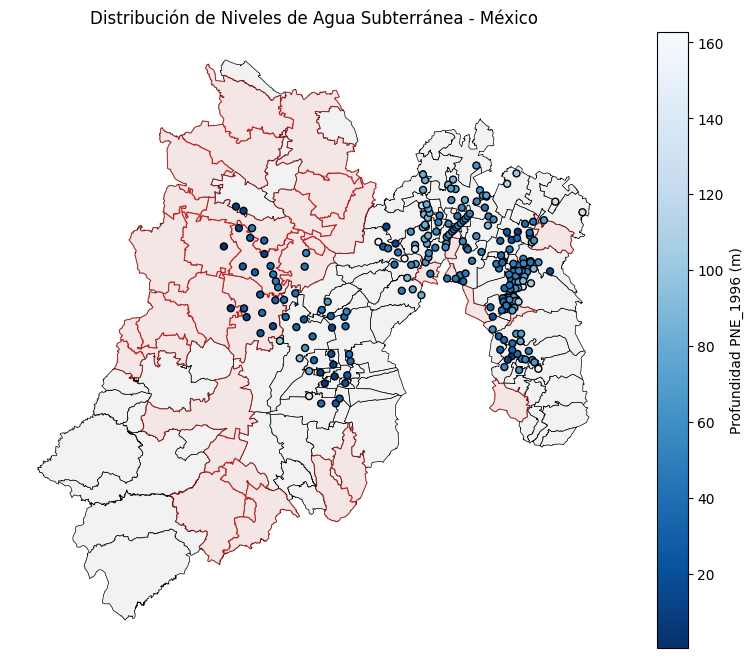

In [14]:
# 1. Carga de la capa de red piezométrica
ruta_piezo = os.path.join(BASE_DIR, "..", "data", "geofiles", "red_piezometrica_2025.shp")
gdf_piezo = gpd.read_file(ruta_piezo)

# --- PASO DE DIAGNÓSTICO: Ver nombres reales de columnas ---
print("Columnas detectadas en el archivo de pozos:")
print(gdf_piezo.columns.tolist())

# 2. Alineación de sistemas de coordenadas (CRS)
gdf_piezo = gdf_piezo.to_crs(gdf_focalizado.crs)

# 3. Intersección espacial
piezo_interseccion = gpd.sjoin(gdf_piezo, gdf_focalizado, how="inner", predicate="within")

# 4. Auto-identificación de la columna de profundidad
# Buscamos columnas que contengan 'PROF' o 'NIVEL' (comunes en archivos de CONAGUA)
posibles_cols = [c for c in piezo_interseccion.columns if 'PROF' in c.upper() or 'NIVEL' in c.upper() or 'NE' in c.upper()]

if posibles_cols:
    col_profundidad = posibles_cols[0]
    print(f"\nUsando la columna '{col_profundidad}' para el análisis de profundidad.")
    
    # 5. Resumen de profundidad por municipio
    resumen_piezo = piezo_interseccion.groupby('NOM_MUN').agg({
        col_profundidad: ['mean', 'min', 'max']
    }).round(2)

    print("\n--- NIVELES DE AGUA (PIEZOMETRÍA) EN METROS ---")
    display(resumen_piezo)
    
    # 6. Visualización
    fig, ax = plt.subplots(figsize=(10, 8))
    gdf_focalizado.plot(ax=ax, color='#f2f2f2', edgecolor='black', linewidth=0.5)
    df_resumen_local.plot(ax=ax, color='#ffcccc', edgecolor='red', alpha=0.3)
    
    piezo_interseccion.plot(ax=ax, column=col_profundidad, cmap='Blues_r', legend=True, 
                            legend_kwds={'label': f"Profundidad {col_profundidad} (m)"},
                            markersize=25, edgecolor='black')
    
    plt.title(f"Distribución de Niveles de Agua Subterránea - {estado_objetivo}")
    plt.axis('off')
    plt.show()
else:
    print("\nERROR: No se encontró una columna de profundidad clara.")
    print("Por favor, revisa la lista de columnas arriba y dime cuál representa la profundidad.")

--- EVOLUCION DEL NIVEL FREATICO (ABATIMIENTO) ---


,Nivel_1996_m,Nivel_2025_m,Descenso_Total_m
NOM_MUN,,,
Coacalco de Berriozábal,57.30,103.90,46.60
Ecatepec de Morelos,44.59,80.29,37.19
Zumpango,66.80,82.53,24.99
Tecámac,63.44,81.50,23.07
Tlalnepantla de Baz,48.66,77.20,22.39
Atizapán de Zaragoza,80.79,69.22,11.95
Naucalpan de Juárez,71.41,90.64,8.62
Hueypoxtla,62.84,81.58,6.59
Acambay,NaN,NaN,NaN


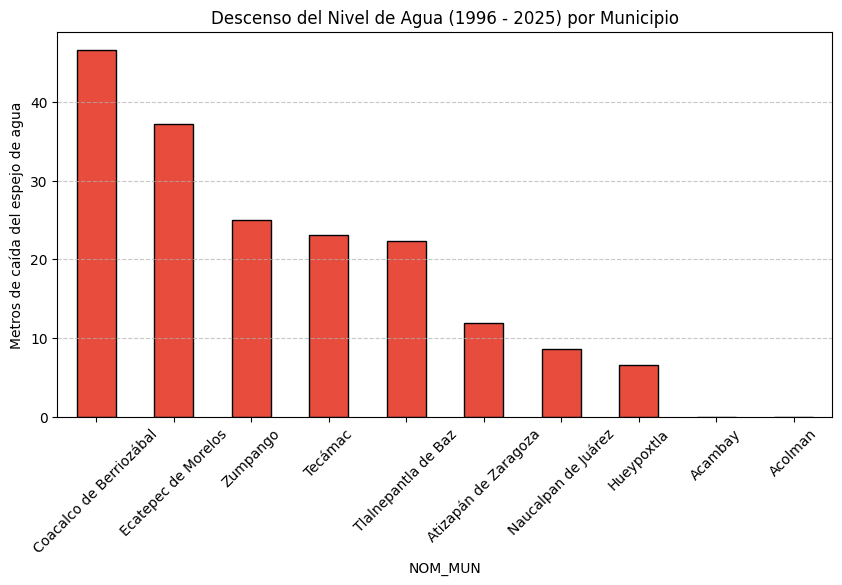

In [15]:
# 1. Definir columnas de interés
col_inicio = 'PNE_1996'
col_actual = 'PNE_2025'

# 2. Calcular la diferencia (Abatimiento)
# Si el valor es positivo, el agua ha bajado (mayor profundidad)
piezo_interseccion['abatimiento_m'] = piezo_interseccion[col_actual] - piezo_interseccion[col_inicio]

# 3. Resumen por municipio crítico
resumen_evolucion = piezo_interseccion.groupby('NOM_MUN').agg({
    col_inicio: 'mean',
    col_actual: 'mean',
    'abatimiento_m': 'mean'
}).rename(columns={
    col_inicio: 'Nivel_1996_m',
    col_actual: 'Nivel_2025_m',
    'abatimiento_m': 'Descenso_Total_m'
}).round(2)

print("--- EVOLUCION DEL NIVEL FREATICO (ABATIMIENTO) ---")
display(resumen_evolucion.sort_values(by='Descenso_Total_m', ascending=False).head(10))

# 4. Grafica de barras de descenso para los 10 mas afectados
resumen_evolucion.sort_values(by='Descenso_Total_m', ascending=False).head(10)['Descenso_Total_m'].plot(
    kind='bar', color='#e74c3c', figsize=(10,5), edgecolor='black'
)
plt.title("Descenso del Nivel de Agua (1996 - 2025) por Municipio")
plt.ylabel("Metros de caída del espejo de agua")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
# 1. Consolidacion de variables clave
# Unimos el resumen de poblacion/deficit con el de piezometria
ficha_intervencion = df_resumen_local.set_index('NOM_MUN').join(resumen_evolucion, how='inner')

# 2. Seleccion de columnas estrategicas para el reporte
columnas_reporte = [
    'Poblacion total', 'DMA_NEGATI', 'lpd_deficit', 
    'Nivel_2025_m', 'Descenso_Total_m'
]

reporte_final = ficha_intervencion[columnas_reporte].sort_values(by='Descenso_Total_m', ascending=False)

# 3. Presentacion de la Ficha Tecnica
print("--- FICHA DE PRIORIZACION DE OBRA HIDRAULICA (ODS 6) ---")
print("Enfoque: Estado de México - Zonas de Abatimiento Crítico\n")
display(reporte_final.head(5))

# 4. Exportacion Final del Notebook 03
ruta_proyecto = os.path.join(PROCESSED_DIR, "propuesta_tecnica_edomex_final.csv")
reporte_final.to_csv(ruta_proyecto, encoding='utf-8-sig')

print(f"\nNotebook 03 finalizado. Proyecto guardado en: {ruta_proyecto}")

--- FICHA DE PRIORIZACION DE OBRA HIDRAULICA (ODS 6) ---
Enfoque: Estado de México - Zonas de Abatimiento Crítico



,Poblacion total,DMA_NEGATI,lpd_deficit,Nivel_2025_m,Descenso_Total_m
NOM_MUN,,,,,
Coacalco de Berriozábal,293444,-480.429914,0.004486,103.9,46.60
Tlalnepantla de Baz,672202,-480.429914,0.001958,77.2,22.39
Acambay,67872,-56.892701,0.002297,NaN,NaN
Aculco,49266,-56.892701,0.003164,NaN,NaN
Almoloya de Juárez,174587,-128.715560,0.002020,NaN,NaN



Notebook 03 finalizado. Proyecto guardado en: C:\Users\Jafet\agua_vulnerabilidad_ods\notebook\..\data\processed\propuesta_tecnica_edomex_final.csv
